# Imports

In [1]:
# Enable autoreloading, delete this for deploying!!!
%load_ext autoreload
%autoreload 2
%load_ext memory_profiler

In [2]:
%%time
import os  # Provides functions to interact with the operating system


# NOTE: UNCOMMENT IF NO GPU AVAILABLE!
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Adjust device IDs as per your setup,

# IBMS Libraries
from scToolkit import sc_code
from scToolkit import sc_plots
from scToolkit import sc_utils
from scToolkit import utils


# Some libraries (e.g., decoupler) may require setting rarely used parallelization
# backends. This function ensures all common thread settings are configured.
# utils.set_threads(10)


/projects/Research/Internal/Proximap/ssd/envs/scToolkit_check_TD/proximap_stable_28_08_2025/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


CUDA devices visible: 0
CPU times: user 7.37 s, sys: 520 ms, total: 7.89 s
Wall time: 4.12 s


In [3]:
# Other general libraries that might be hepflull for analysis

import re  # Enables regular expression matching and text processing
import time  # Offers time-related functions (e.g., sleep, timestamps)
# in Python, most assignments are references (symbolic links), not copies
from copy import deepcopy as copy  # Creates deep copies of complex objects
import scanpy as sc  # Toolkit for analyzing single-cell gene expression data
import anndata as ad  # Provides AnnData structure for annotated data matrices
import seaborn as sns  # Simplifies creation of attractive statistical plots
import numpy as np  # Supports numerical operations and N-dimensional arrays
import pandas as pd  # Offers data structures and tools for data analysis
import matplotlib.pyplot as plt  # Enables plotting and figure customization
from itertools import combinations  # Generates all k-length combinations of an iterable
import scipy.stats as stats  # Contains statistical distributions and test functions


# Define rcParams for customization, notebook showing is figure.dpi, reduce to not overload the nootebook sizes
plt.rcParams.update({
    # "figure.figsize": (8, 6),  # Figure size in inches
    "savefig.dpi": 400,       # Dots per inch for saved figures
    "figure.dpi": 100,       # Dots per inch for saved figures
    #"axes.titlesize": 16,     # Title font size
    #"axes.labelsize": 14,     # Label font size
    #"xtick.labelsize": 12,    # X-axis tick label size
    #"ytick.labelsize": 12     # Y-axis tick label size
})

# Setup matplotlib notebook backend
%matplotlib inline


In [4]:
start = time.time()

# Load the Adata object

In [5]:
%%time

adata = sc_code.load_h5ad("../data/01_tonsil_blood_DISCO_preprocessed.h5ad")

CPU times: user 24.2 s, sys: 2.28 s, total: 26.5 s
Wall time: 26.5 s


# Object Preprocessing for GSE and clustering

In [6]:
adata.uns["config"]["qc"]["gene_identifiers"].keys()

dict_keys(['HK_gtex', 'HK_cellminer', 'HK_hpa', 'HK_klijn', 'HK_human', 'HK_hrt', 'HK_hk_union', 'HK_hk_intersect', 'HK_hk_intersect_no_hrt', 'GTF_IG_genes', 'GTF_processed_transcripts', 'GTF_pseudogenes', 'GTF_TR_genes', 'GTF_RBS', 'GTF_protein_coding', 'HGNC_non_coding_RNA', 'HGNC_other', 'HGNC_protein_coding_gene', 'HGNC_pseudogene', 'MT', 'RBS', 'MTRBS', 'PSEUDO', 'HG'])

In [7]:
# Setup genes to exclude based on biological irrelevance and artifacts

# The qc genesets are saved in:
# adata.uns["config"]["qc"]["gene_identifiers"].keys()
#['mousekeeping', 'hrt', 'IG_genes', 'processed_transcripts', 'pseudogenes', 'TR_genes',
# 'MT', 'RBS', 'protein_coding', 'MTRBS', 'death', 'NIMA', 'meiosis', 'cell_division', 'cell_replication',
# 'cell_cycle', 'GTPase', 'ATPase', 'defensin', 'heat_shock', 'stress', 'caspase', 'TNF', 'inflam_2', 'oncogene', 'HG']

# Most of them are necessary, but there are genes where differences in expression
# are driven by biological processes not relevant to the analysis — for example,
# genes related to energy production (such as mitochondrial [MT] and ribosomal
# [RBS] genes), replication, or potential artifacts (such as hemoglobin [HG]
# genes), as well as TEC (to be experimentally confirmed) and pseudogenes.

# adding custom genesets via:
# adata.uns["config"]["qc"]["gene_identifiers"]["custom"] = "^Gene1$|reg.*ex"  # Read a regex tutorial if you don't understand this

# Here we remove the Mitochondrial, ribosomoal, mitoribosomal, TEC genes and pseudogenes 
# Adjust this to your needs.
adata.uns["config"]["exclude_gene_family_regex"] = [
    adata.uns["config"]["qc"]["gene_identifiers"][x] 
    for x in ["MT", "HG", "RBS", "PSEUDO"]]

# NOTE: You have to be certain about gene removal; excluding relevant genes may
# hurt performance. Sometimes this is an iterative process 
# for example, PBMC clustering may require removing TCR genes.

# Setup: Genes to Exclude Based on Biological Irrelevance and Artifacts

The QC genesets are stored in:

`adata.uns["config"]["qc"]["gene_identifiers"].keys()`

These include:  
`mousekeeping`, `hrt`, `IG_genes`, `processed_transcripts`, `pseudogenes`,  
`TR_genes`, `MT`, `RBS`, `protein_coding`, `MTRBS`, `death`,  
`NIMA`, `meiosis`, `cell_division`, `cell_replication`, `cell_cycle`,  
`GTPase`, `ATPase`, `defensin`, `heat_shock`, `stress`,  
`caspase`, `TNF`, `inflam_2`, `oncogene`, `HG`

Some gene groups reflect processes unrelated to the biological focus of your analysis — for example:

- **Energy metabolism**: mitochondrial (`MT`), ribosomal (`RBS`, `MTRBS`)
- **Artifacts**: hemoglobin (`HG`)
- **Non-informative**: pseudogenes, TEC (to be validated)

These can be excluded to reduce irrelevant biological or technical signals.

To add custom gene sets:

`adata.uns["config"]["qc"]["gene_identifiers"]["custom_regex"] = "^GENE1$|reg.*ex"`  
`adata.uns["config"]["qc"]["gene_identifiers"]["custom_list"] = [GENE1, "GENE2"]`

To define which gene families to exclude:

```python
adata.uns["config"]["exclude_gene_family_regex"] = [
    adata.uns["config"]["qc"]["gene_identifiers"][x]
    for x in ["MT", "HG", "GTF_RBS", "GTF_pseudogenes"]]
```

> **Note**: 
    You have to be certain about gene removal; excluding relevant genes may  
    hurt performance. Sometimes this is an iterative process  
    for example, PBMC clustering may require removing TCR genes.

In [8]:
# Run the Preprocessing for GSE and Clustering

# This function performs a series of preprocessing steps on the provided AnnData object, including
# filtering genes, normalization, log-transforming, scaling, and regression. The steps are configurable based on the
# settings in `adata.uns["config"]`. It also handles saving intermediate results in `adata.layers`
# and updating the preprocessing status in `adata.uns["stats"]["preprocessors_ran"]`.


# NOTE: We filtering here refers to the gene removal by geneset we defined in the previous cell
adata = sc_code.Run_all_prep_steps_clustering(adata)

# NOTE: After the execution the adata.X is scaled, which is default for the PCA but not used anywhere else. 
#       ALWAYS CHECK WHICH DATA FORMAT EACH ALGORITHM REQUIRES — CALCULATING DEGs ON Z-SCORES IS INCORRECT!

INFO:sc_code.py:Run_all_prep_steps_clustering - ################################################################################
Started Raw Count Preprocessing
################################################################################
INFO:sc_code.py:Run_all_prep_steps_clustering - Running Regex gene exclusion
INFO:sc_code.py:Run_all_prep_steps_clustering - Normalization time: 9.996161460876465
INFO:sc_code.py:Run_all_prep_steps_clustering - Scaling data...
INFO:sc_code.py:Run_all_prep_steps_clustering - ################################################################################
Finished RNA Preprocessing after 71.97963285446167 seconds
################################################################################


In [9]:
# NOTE: Here we can see the layers now and that we have less genes.
adata

AnnData object with n_obs × n_vars = 573115 × 8497
    obs: 'orig.ident', 'ncount_rna', 'nfeature_rna', 'sample', 'sample_id', 'project_id', 'sample_type', 'disease', 'tissue', 'platform', 'disease_subtype', 'time_point', 'subject_id', 'age', 'gender', 'race', 'infection', 'disease_stage', 'mutation', 'predicted_cell_type', 'ct', 'sub.cluster', 'pct_gtex', 'pct_hpa', 'pct_hrt', 'pct_cellminer', 'pct_klijn', 'pct_IG_C_gene', 'pct_IG_C_pseudogene', 'pct_IG_J_gene', 'pct_IG_V_gene', 'pct_IG_V_pseudogene', 'pct_TR_C_gene', 'pct_TR_J_gene', 'pct_TR_J_pseudogene', 'pct_TR_V_gene', 'pct_TR_V_pseudogene', 'pct_lncRNA', 'pct_miRNA', 'pct_protein_coding', 'pct_ribozyme', 'pct_snRNA', 'pct_snoRNA', 'pct_pseudogenes_hg', 'n_unique', 'study_category', 'barcode', 'donor_id', 'gem_id', 'library_name', 'assay', 'sex', 'age_group', 'hospital', 'cohort_type', 'cause_for_tonsillectomy', 'is_hashed', 'preservation', 'annotation_level_1', 'annotation_level_1_probability', 'annotation_figure_1', 'annotation

In [10]:
# Run the Preprocessing for GSE and Clustering

# This function performs a series of preprocessing steps on the provided AnnData object, including
# filtering genes, normalization, log-transforming, scaling, and regression. The steps are configurable based on the
# settings in `adata.uns["config"]`. It also handles saving intermediate results in `adata.layers`
# and updating the preprocessing status in `adata.uns["stats"]["preprocessors_ran"]`.

# NOTE: We filtering here refers to the gene removal by geneset we defined in the previous cell
adata = sc_code.Run_all_prep_steps_clustering(adata)

# NOTE: After the execution the adata.X is scaled, which is default for the PCA but not used anywhere else. 
#       ALWAYS CHECK WHICH DATA FORMAT EACH ALGORITHM REQUIRES — CALCULATING DEGs ON Z-SCORES IS INCORRECT!

# GSE Marker Scoring

## Cell Types

### Get the Genesets

In [11]:
combined_database = sc_code.get_ref_db(
        db="Combined", organism="human") # Default databases are ["PanglaoDB", "CellMarker", "SCType", "CellTypist"], 
# These are the most common cell type databases in one table
combined_database.head(2)

,genesymbol,cell_type,germ_layer,specificity,tissue,presence,db,tissue_specific,cancer_type,condition,other_marker_name,gene_function,genesymbol_down
1,CTRB1,Acinar cells,Endoderm,0.000629,Pancreas,0.017,PanglaoDB,NaN,NaN,NaN,NaN,NaN,NaN
2,KLK1,Endothelial cells,Mesoderm,0.008420,Vasculature,0.013,PanglaoDB,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
combined_database["db"].unique()

array(['PanglaoDB', 'CellTypist', 'CellMarker', 'SCType'], dtype=object)

- **genesymbol**: Gene symbol (official short name of the gene).
- **cell_type**: Cell type where the gene is predominantly expressed.
- **germ_layer**: Embryonic germ layer origin (e.g., endoderm, ectoderm, mesoderm).
- **specificity**: Specificity score indicating how uniquely the gene marks this cell type.
- **tissue**: Tissue where the gene is primarily expressed.
- **presence**: Frequency or fraction of cells expressing this gene in the tissue.
- **db**: Source database or reference for the marker information.
- **tissue_specific**: Whether the gene is considered tissue-specific (if annotated).
- **cancer_type**: Associated cancer type, if relevant.
- **condition**: Condition or disease context for this gene, if applicable.
- **other_marker_name**: Alternative marker names or aliases.
- **gene_function**: Known biological function of the gene.
- **genesymbol_down**: Related downregulated gene symbol, if applicable.


#### Tutorial how to search the database

Use `search_database` to flexibly filter a column using OR, AND, and NOT terms, with optional case sensitivity.

**OR search** (at least one term matches):  
`search_database(db, search_term_or=["mitophagy", "pexophagy"])`

**AND search** (all terms must match):  
`search_database(db, search_term_and="astro")`

**Combine OR and AND**:  
`search_database(db, search_term_or=["mitophagy", "pexophagy"], search_term_and=["gobp"])`

**Add NOT terms** (exclude entries):  
`search_database(db, search_term_or=["mitophagy", "pexophagy"], search_term_and=["gobp"], search_term_not_and=["response"])`

**Control case sensitivity**:  
Use `lower_search_space_and=False`, `lower_search_space_or=False`, etc., to make searches **case-sensitive**. By default, all are `True` (case-insensitive).

**Return boolean mask (indices)**:  
`mask = search_database(db, search_term_and="astro", return_indices=True); db[mask]`


In [13]:
# This is an iterative process; you should check the gene set names after each change
# to refine the final list.

cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["T Cell"],
    lower_search_space_or=False,
)
print(f"Number of cell types matching exactly 'T Cell': {len(cell_types)}")

cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
    lower_search_space_or=False,
)
print(f"Number of cell types matching any T Cell variants: {len(cell_types)}")

cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
    lower_search_space_or=False,
    search_term_not_or=["natural killer", "nk"],
)
print(f"Number of T cell-related types excluding NK cells: {len(cell_types)}")

Number of cell types matching exactly 'T Cell': 2
Number of cell types matching any T Cell variants: 191
Number of T cell-related types excluding NK cells: 185


#### Tutorial how to select genes per cell-type

The function `get_element_and_counts_with_positional_sum` summarizes marker genes across selected cell types or groups.

##### Example output columns

| gene  | gs_count | gs_count_pct | total_count | cell_types                    | highly_variable_rank |
|---------|-----------|---------------|-------------|-------------------------------|----------------------|
| Cd8a | 56    | 17.39      | 86     | T cells, Effector CD8+ T cell, ... | 35.0                   |

- **gene**: Gene symbol.
- **gs_count**: Number of times this gene appears in your subsetted group.
- **gs_count_pct**: Percentage of group cell types expressing this gene.
- **total_count**: Total times this gene appears across the whole database.
- **cell_types**: All cell types where this gene was found (joined as a string).
- **highly_variable_rank**: Rank of gene variability (added if `adata` provided).

##### How to use - and for manuall refinement

To get a detailed DataFrame preview (use `.head(5)` to show first 5 rows):  
```python
sc_utils.get_element_and_counts_with_positional_sum(
    subsetted_df, 
    combined_database, 
    adata=adata, 
    return_list=False
).head(5)

To get a sorted list of top genes:  
`gene_list = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database, adata=adata); print(gene_list[:n_genes])`

To store top genes in a marker dictionary:  
`marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database, adata=adata)[:n_genes]`

If you want to change the default sorting after getting the DataFrame, you can manually re-sort it using different columns.  
For example, to prioritize genes with higher total counts and then sort by highly variable gene rank, you can do:  

`df = sc_utils.get_element_and_counts_with_positional_sum(
    subsetted_df,
    combined_database,
    adata=adata,
    return_list=False,
    sort_columns=["gs_count", "highly_variable_rank"],
    ascending=[False, True]
)`

### Get the cell-type marker_dict 
keys = cell-type name  
values = list of genes   
This is our prefered data format for genesets.

In [14]:
# Define the number of genes per gene set
n_genes = 20

# create the empyt marker dict
ct_marker_dict = {}
############################################################################################################################################
# Immune and Blood cell
############################################################################################################################################

this_ct_key = "plasma_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(
    combined_database, "plasm",
    search_term_not_or=["b cell", "dendritic", "malig", "abnorm"],)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

############################################################################################################################################
this_ct_key = "macrophage_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(combined_database, "macro")
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

############################################################################################################################################
this_ct_key = "dendritic_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(combined_database, "dendri")
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

###########################################################################################
this_ct_key = "b_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["B Cell", "B cell", "B-cell", "B-Cell"],
    lower_search_space_or=False,
    search_term_not_or=["natural killer", "nk"],
)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

###########################################################################################
this_ct_key = "t_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
    lower_search_space_or=False,
    search_term_not_or=["natural killer", "nk"],
)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

###########################################################################################
this_ct_key = "nk_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["natural killer", "nk"],
    lower_search_space_or=True,
    search_term_not_or=[
        "T Cell", "T cell", "T-cell", "T-Cell",
        "B Cell", "B cell", "B-cell", "B-Cell"
    ],
    lower_search_space_not_or=False,
)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

###########################################################################################
this_ct_key = "activated_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
a = sc_utils.search_database(
    combined_database,
    search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
    lower_search_space_or=False,
    search_term_not_or=["natural killer", "nk"],
)
b = sc_utils.search_database(combined_database, "activated")
cell_types = np.intersect1d(a, b)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

###########################################################################################
this_ct_key = "exhausted_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
a = sc_utils.search_database(
    combined_database,
    search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
    lower_search_space_or=False,
    search_term_not_or=["natural killer", "nk"],
)
b = sc_utils.search_database(combined_database, "exhausted")
cell_types = np.intersect1d(a, b)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(subsetted_df, combined_database)[:n_genes]

############################################################################################################################################
this_ct_key = "endothelial_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["endothe"],
)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(
    subsetted_df, combined_database
)[:n_genes]

############################################################################################################################################
this_ct_key = "granulocyte_cells"
print("#" * 80)
print(this_ct_key)
print("#" * 80)
cell_types = sc_utils.search_database(
    combined_database,
    search_term_or=["granuloc", "eosin", "baso"],
)
subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
ct_marker_dict[this_ct_key] = sc_utils.get_element_and_counts_with_positional_sum(
    subsetted_df, combined_database
)[:n_genes]

####################################
# Grouping the cell types and save the info in the adata.uns
general_cells = [
    "plasma_cells", "macrophage_cells", "dendritic_cells", "b_cells",
    "t_cells", "nk_cells", "endothelial_cells",
    "granulocyte_cells"
]

activated_exhauseted_cells = [
    "activated_cells", "exhausted_cells"
]

# malignant_cells = [
#     "malginant_cells", "aml_cells"
# ]

adata.uns["cell_type_info"] = {}
adata.uns["cell_type_info"]["general_cells"] = general_cells
adata.uns["cell_type_info"]["activated_exhauseted_cells"] = activated_exhauseted_cells

################################################################################
plasma_cells
################################################################################
################################################################################
macrophage_cells
################################################################################
################################################################################
dendritic_cells
################################################################################
################################################################################
b_cells
################################################################################
################################################################################
t_cells
################################################################################
################################################################################
nk_cells
######################################

## Grouping and saving in the adata object

In [15]:
# Store the genesets at the correct postion for the automated donwstream processing
adata.uns["genesets"] = {}
adata.uns["genesets"]["cell_type_markers"] = copy(ct_marker_dict)

# Create the full marker dict for GSE, then we only need to perform one run
gse_marker_dict = {}
gse_marker_dict.update(ct_marker_dict)

## Running GSE - ORA with significance thresholds

In [16]:
# NOTE: For GSE we need log norm data
adata.X = adata.layers["log2norm_counts"].copy() 
# NOTE: The copy is mandatory, because Decoupler sometimes fails and replaces values in the data 
#       As well as the scanpy default cluster preprocessing functions (PCA, Neighbors, ...)

In [17]:
%%time
sc_code.run_decoupler(
        adata, run_type="ora", ref=gse_marker_dict, verbose=True, min_n=3)

Running ora on mat with 573115 samples and 8497 targets for 10 sources.


100%|█████████████████████████████████████████████████████████████████████████| 573115/573115 [03:24<00:00, 2798.62it/s]


CPU times: user 2h 30min 17s, sys: 6.46 s, total: 2h 30min 23s
Wall time: 3min 39s


In [18]:
adata

AnnData object with n_obs × n_vars = 573115 × 8497
    obs: 'orig.ident', 'ncount_rna', 'nfeature_rna', 'sample', 'sample_id', 'project_id', 'sample_type', 'disease', 'tissue', 'platform', 'disease_subtype', 'time_point', 'subject_id', 'age', 'gender', 'race', 'infection', 'disease_stage', 'mutation', 'predicted_cell_type', 'ct', 'sub.cluster', 'pct_gtex', 'pct_hpa', 'pct_hrt', 'pct_cellminer', 'pct_klijn', 'pct_IG_C_gene', 'pct_IG_C_pseudogene', 'pct_IG_J_gene', 'pct_IG_V_gene', 'pct_IG_V_pseudogene', 'pct_TR_C_gene', 'pct_TR_J_gene', 'pct_TR_J_pseudogene', 'pct_TR_V_gene', 'pct_TR_V_pseudogene', 'pct_lncRNA', 'pct_miRNA', 'pct_protein_coding', 'pct_ribozyme', 'pct_snRNA', 'pct_snoRNA', 'pct_pseudogenes_hg', 'n_unique', 'study_category', 'barcode', 'donor_id', 'gem_id', 'library_name', 'assay', 'sex', 'age_group', 'hospital', 'cohort_type', 'cause_for_tonsillectomy', 'is_hashed', 'preservation', 'annotation_level_1', 'annotation_level_1_probability', 'annotation_figure_1', 'annotation

In [19]:
# Saving the data layers twice creates a overhead, we remove the X layer here.
# it was scaled data, so dense and therefore basically having more than 70% of 
# the size of the object. Having it twice is inefficient
# NOTE: BUT Scanpys functions don't check if the X is none, so make sure to reset the X to the desired layer!
adata.X = None

# Rest

In [20]:
end = time.time() - start
print(f"Finished Full Preprocessing in {end:.2f} seconds.")

Finished Full Preprocessing in 332.11 seconds.


In [21]:
%%time
sc_code.save_h5ad(adata, "../data/02_tonsil_blood_DISCO_clustering_preprocessed.h5ad", compression="lzf")

CPU times: user 3min 18s, sys: 6.75 s, total: 3min 25s
Wall time: 3min 25s


In [22]:
adata

AnnData object with n_obs × n_vars = 573115 × 8497
    obs: 'orig.ident', 'ncount_rna', 'nfeature_rna', 'sample', 'sample_id', 'project_id', 'sample_type', 'disease', 'tissue', 'platform', 'disease_subtype', 'time_point', 'subject_id', 'age', 'gender', 'race', 'infection', 'disease_stage', 'mutation', 'predicted_cell_type', 'ct', 'sub.cluster', 'pct_gtex', 'pct_hpa', 'pct_hrt', 'pct_cellminer', 'pct_klijn', 'pct_IG_C_gene', 'pct_IG_C_pseudogene', 'pct_IG_J_gene', 'pct_IG_V_gene', 'pct_IG_V_pseudogene', 'pct_TR_C_gene', 'pct_TR_J_gene', 'pct_TR_J_pseudogene', 'pct_TR_V_gene', 'pct_TR_V_pseudogene', 'pct_lncRNA', 'pct_miRNA', 'pct_protein_coding', 'pct_ribozyme', 'pct_snRNA', 'pct_snoRNA', 'pct_pseudogenes_hg', 'n_unique', 'study_category', 'barcode', 'donor_id', 'gem_id', 'library_name', 'assay', 'sex', 'age_group', 'hospital', 'cohort_type', 'cause_for_tonsillectomy', 'is_hashed', 'preservation', 'annotation_level_1', 'annotation_level_1_probability', 'annotation_figure_1', 'annotation

### Check the occurances

In [23]:
from scToolkit import (Any, pd, ad, validate_groupby_column, 
                        Counter, defaultdict)

def jaccard_numpy(a, b):
    a = np.unique(a)
    b = np.unique(b)
    all_genes = np.union1d(a, b)
    mask_a = np.isin(all_genes, a)
    mask_b = np.isin(all_genes, b)
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return inter / union if union > 0 else 0.0


def get_cell_types(combined_database: pd.DataFrame, use_this_ct: str) -> list[str]:
    """
    Retrieve matching cell-type names from a database based on category key.

    Args:
        combined_database (pd.DataFrame): Database containing cell-type names.
        use_this_ct (str): Cell-type category to query (e.g., "b_cells").

    Returns:
        list[str]: Matched cell-type names.
    """
    # #########################################################
    # Match-case block for supported cell-type identifiers
    # #########################################################
    match use_this_ct:
        case "plasma_cells":
            return sc_utils.search_database(
                combined_database,
                "plasm",
                search_term_not_or=["b cell", "dendritic", "malig",],
            )

        case "macrophage_cells":
            return sc_utils.search_database(combined_database, "macro")

        case "dendritic_cells":
            return sc_utils.search_database(combined_database, "dendri")

        case "b_cells":
            return sc_utils.search_database(
                combined_database,
                search_term_or=["B Cell", "B cell", "B-cell", "B-Cell"],
                lower_search_space_or=False,
                search_term_not_or=["natural killer", "nk"],
            )

        case "t_cells":
            return sc_utils.search_database(
                combined_database,
                search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
                lower_search_space_or=False,
                search_term_not_or=["natural killer", "nk"],
            )

        case "nk_cells":
            return sc_utils.search_database(
                combined_database,
                search_term_or=["natural killer", "nk"],
                lower_search_space_or=True,
                search_term_not_or=[
                    "T Cell", "T cell", "T-cell", "T-Cell",
                    "B Cell", "B cell", "B-cell", "B-Cell",
                ],
                lower_search_space_not_or=False,
            )

        case "activated_cells":
            a = sc_utils.search_database(
                combined_database,
                search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
                lower_search_space_or=False,
                search_term_not_or=["natural killer", "nk"],
            )
            b = sc_utils.search_database(combined_database, "activated")
            return np.intersect1d(a, b).tolist()

        case "exhausted_cells":
            a = sc_utils.search_database(
                combined_database,
                search_term_or=["T Cell", "T cell", "T-cell", "T-Cell"],
                lower_search_space_or=False,
                search_term_not_or=["natural killer", "nk"],
            )
            b = sc_utils.search_database(combined_database, "exhausted")
            return np.intersect1d(a, b).tolist()

        case "endothelial_cells":
            return sc_utils.search_database(
                combined_database,
                search_term_or=["endothe"],
            )

        case "granulocyte_cells":
            return sc_utils.search_database(
                combined_database,
                search_term_or=["granuloc", "eosin", "baso"],
            )

        case _:
            raise ValueError(f"Unsupported cell type: {use_this_ct}")

In [24]:
all_jaccard_rows = []

for x in general_cells:
 
    cell_types = get_cell_types(combined_database, x)
    
    # Reference gene set (our method)
    subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
    our_method_genes = set(
        sc_utils.get_element_and_counts_with_positional_sum(
            subsetted_df, combined_database, use_pct_key="pct_log2p"
        )[:n_genes]
    )

    print("#" * 80)
    print(x)
    print("#" * 80)

    # Define refined and rest parts
    refined_db = combined_database[combined_database["cell_type"].isin(cell_types)]
    rest_df = combined_database[~combined_database["cell_type"].isin(cell_types)]

    # Group-level gene sets
    refined_groups = {
        (cell_type, db, tissue): set(group_df["genesymbol"])
        for (cell_type, db, tissue), group_df in refined_db.groupby(["cell_type", "db", "tissue"])
    }

    rest_groups = {
        (cell_type, db, tissue): set(group_df["genesymbol"])
        for (cell_type, db, tissue), group_df in rest_df.groupby(["cell_type", "db", "tissue"])
    }

    # ---- Part 1: Compare rest groups vs our_method ----
    for (r_cell, r_db, r_tissue), rest_genes in rest_groups.items():
        if not rest_genes:
            continue
        overlap = len(rest_genes & our_method_genes)
        if overlap <= 0:
            continue

        jaccard_val = jaccard_numpy(list(rest_genes), list(our_method_genes))
        all_jaccard_rows.append({
            "x": x,
            "is_ref": True,
            "rest_cell_type": r_cell,
            "rest_db": r_db,
            "rest_tissue": r_tissue,
            "refined_cell_type": None,
            "refined_db": None,
            "refined_tissue": None,
            "jaccard_value": jaccard_val,
            "overlap_count": overlap
        })

    # ---- Part 2: Compare rest groups vs all refined groups ----
    for (r_cell, r_db, r_tissue), rest_genes in rest_groups.items():
        if not rest_genes:
            continue
        for (c_cell, c_db, c_tissue), ref_genes in refined_groups.items():
            if not ref_genes:
                continue

            overlap = len(rest_genes & ref_genes)
            if overlap <= 0:
                continue

            jaccard_val = jaccard_numpy(list(rest_genes), list(ref_genes))
            all_jaccard_rows.append({
                "x": x,
                "is_ref": False,
                "rest_cell_type": r_cell,
                "rest_db": r_db,
                "rest_tissue": r_tissue,
                "refined_cell_type": c_cell,
                "refined_db": c_db,
                "refined_tissue": c_tissue,
                "jaccard_value": jaccard_val,
                "overlap_count": overlap
            })

# Combine into a single long-format DataFrame
all_jaccard_df = pd.DataFrame(all_jaccard_rows)

################################################################################
plasma_cells
################################################################################
################################################################################
macrophage_cells
################################################################################
################################################################################
dendritic_cells
################################################################################
################################################################################
b_cells
################################################################################
################################################################################
t_cells
################################################################################
################################################################################
nk_cells
######################################

In [25]:
all_jaccard_rows = []

for x in general_cells:
 
    cell_types = get_cell_types(combined_database, x)
    
    # Reference gene set (our method)
    subsetted_df = combined_database[combined_database["cell_type"].isin(cell_types)]
    our_method_genes = set(
        sc_utils.get_element_and_counts_with_positional_sum(
            subsetted_df, combined_database, use_pct_key="pct_log2p"
        )[:n_genes]
    )

    print("#" * 80)
    print(x)
    print("#" * 80)

    # Define refined and rest parts
    refined_db = combined_database[combined_database["cell_type"].isin(cell_types)]
    rest_df = combined_database[~combined_database["cell_type"].isin(cell_types)]

    # Group-level gene sets
    refined_groups = {
        (cell_type, db, tissue): set(group_df["genesymbol"])
        for (cell_type, db, tissue), group_df in refined_db.groupby(["cell_type", "db", "tissue"])
    }

    rest_groups = {
        (cell_type, db, tissue): set(group_df["genesymbol"])
        for (cell_type, db, tissue), group_df in rest_df.groupby(["cell_type", "db", "tissue"])
    }

    # ---- Part 1: Compare rest groups vs our_method ----
    # collect all overlaps
    overlap_list = []
    for (r_cell, r_db, r_tissue), rest_genes in rest_groups.items():
        overlap_genes = rest_genes & our_method_genes
        overlap_size = len(overlap_genes)
        if overlap_size > 0:
            overlap_list.append(((r_cell, r_db, r_tissue), rest_genes, overlap_genes, overlap_size))
    
    # sort from smallest to largest overlap
    overlap_list = sorted(overlap_list, key=lambda x: x[3])
    
    # --- precompute cumulative unions from bottom to top ---
    cumulative_union_sets = []
    current_union = set()
    for _, _, overlap_genes, _ in overlap_list:
        current_union |= overlap_genes
        cumulative_union_sets.append(current_union.copy())
    
    # now iterate again, this time attaching correct "genes_left"
    for idx, ((r_cell, r_db, r_tissue), rest_genes, overlap_genes, overlap_size) in enumerate(overlap_list):
        # genes left after unifying all smaller-overlapping sets (bottom→this)
        genes_left = our_method_genes - cumulative_union_sets[idx]
        remaining_overlap = len(genes_left)
    
        jaccard_val = jaccard_numpy(list(rest_genes), list(our_method_genes))
    
        all_jaccard_rows.append({
            "x": x,
            "is_ref": True,
            "rest_cell_type": r_cell,
            "rest_db": r_db,
            "rest_tissue": r_tissue,
            "refined_cell_type": None,
            "refined_db": None,
            "refined_tissue": None,
            "jaccard_value": jaccard_val,
            "overlap_count": overlap_size,
            "removed_genes": overlap_genes,
            "genes_kept": our_method_genes - overlap_genes,
            "genes_left": genes_left,
            "remaining_overlap": remaining_overlap
        })

    # ---- Part 2: Compare rest groups vs all refined groups ----
    covered_genes = set()  # <-- added initialization for correct tracking
    for (r_cell, r_db, r_tissue), rest_genes in rest_groups.items():
        if not rest_genes:
            continue
        for (c_cell, c_db, c_tissue), ref_genes in refined_groups.items():
            if not ref_genes:
                continue

            overlap_genes = rest_genes & ref_genes
            overlap_size = len(overlap_genes)
            if overlap_size <= 0:
                continue

            # Update covered_genes
            covered_genes |= overlap_genes

            # Gene tracking logic (same structure)
            removed_genes = overlap_genes
            genes_kept = ref_genes - overlap_genes
            genes_left = our_method_genes - covered_genes
            remaining_overlap = len(genes_left)

            # Jaccard calculation
            jaccard_val = jaccard_numpy(list(rest_genes), list(ref_genes))

            all_jaccard_rows.append({
                "x": x,
                "is_ref": False,
                "rest_cell_type": r_cell,
                "rest_db": r_db,
                "rest_tissue": r_tissue,
                "refined_cell_type": c_cell,
                "refined_db": c_db,
                "refined_tissue": c_tissue,
                "jaccard_value": jaccard_val,
                "overlap_count": overlap_size,
                "removed_genes": removed_genes,
                "genes_kept": genes_kept,
                "genes_left": genes_left,
                "remaining_overlap": remaining_overlap
            })

# Combine into a single long-format DataFrame
all_jaccard_df = pd.DataFrame(all_jaccard_rows)

################################################################################
plasma_cells
################################################################################
################################################################################
macrophage_cells
################################################################################
################################################################################
dendritic_cells
################################################################################
################################################################################
b_cells
################################################################################
################################################################################
t_cells
################################################################################
################################################################################
nk_cells
######################################

In [26]:
save_dir = "../Figures/barplots"

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/b_cells_top200_sum.pdf


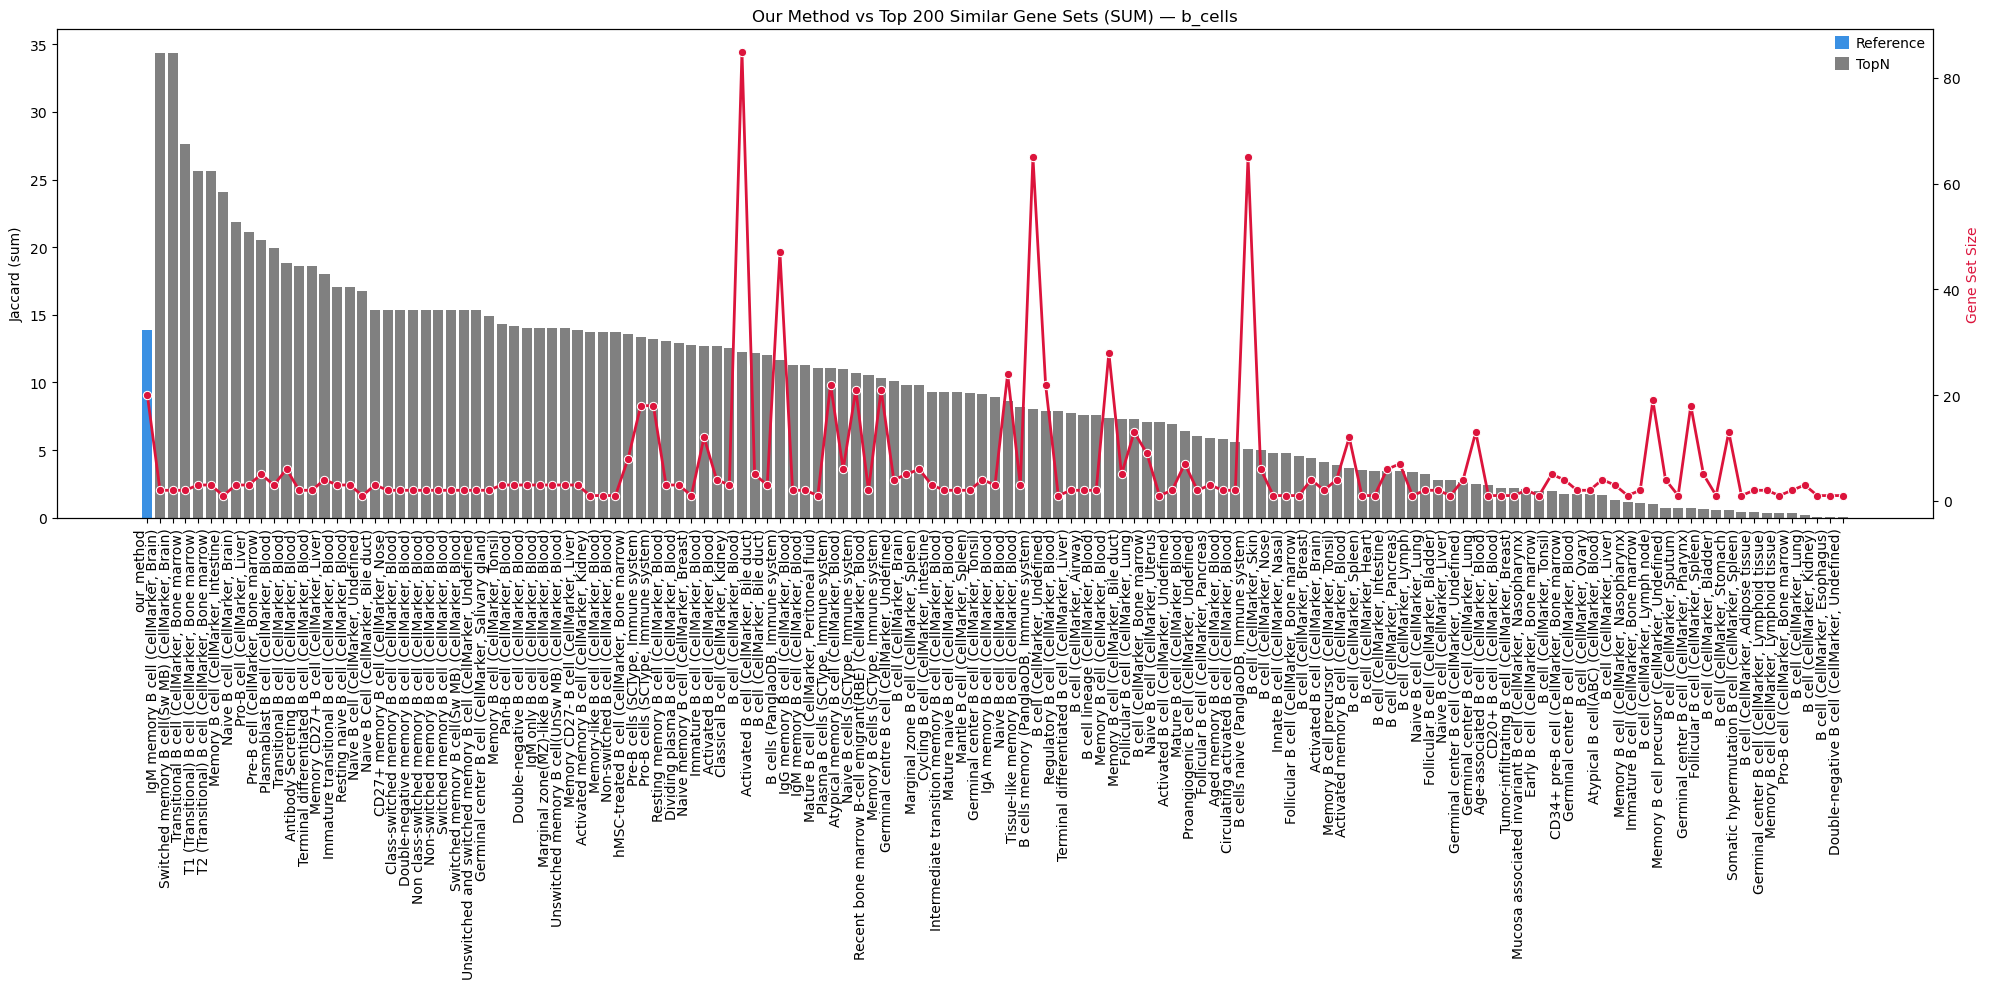

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/dendritic_cells_top200_sum.pdf


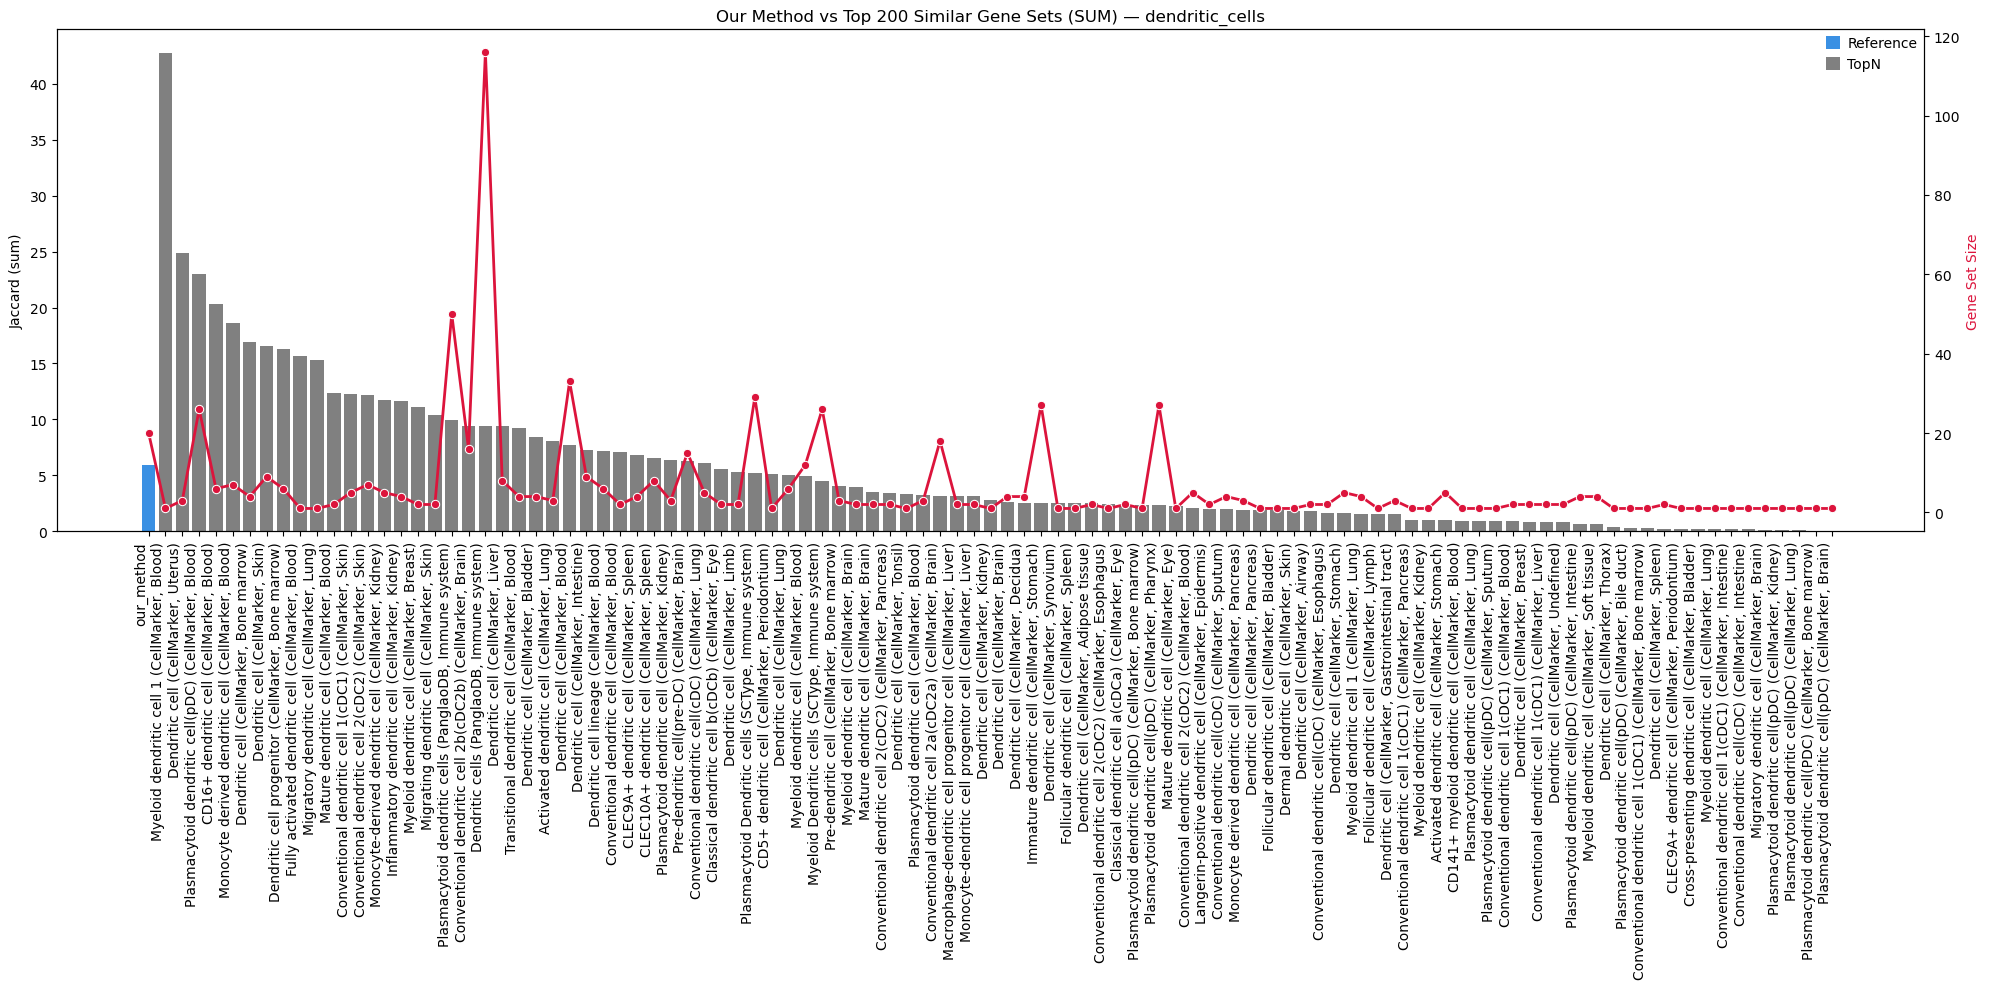

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/endothelial_cells_top200_sum.pdf


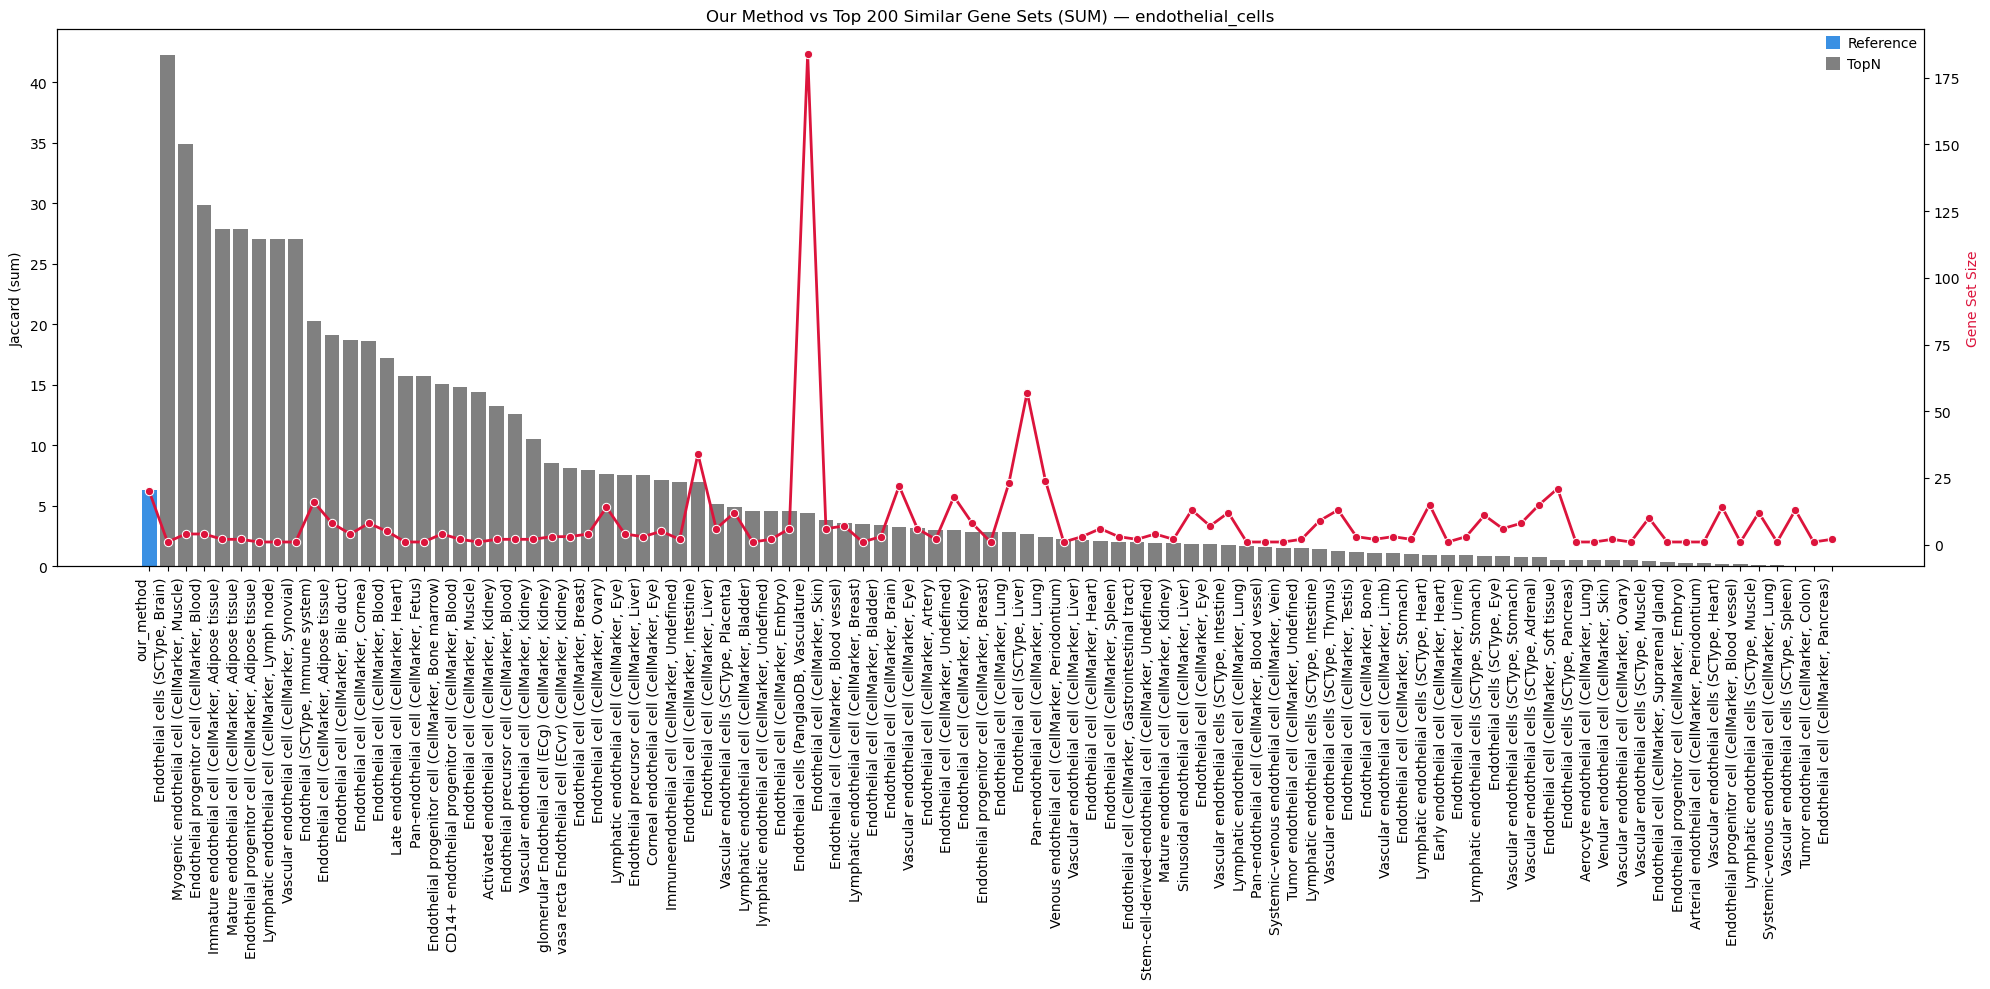

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/granulocyte_cells_top200_sum.pdf


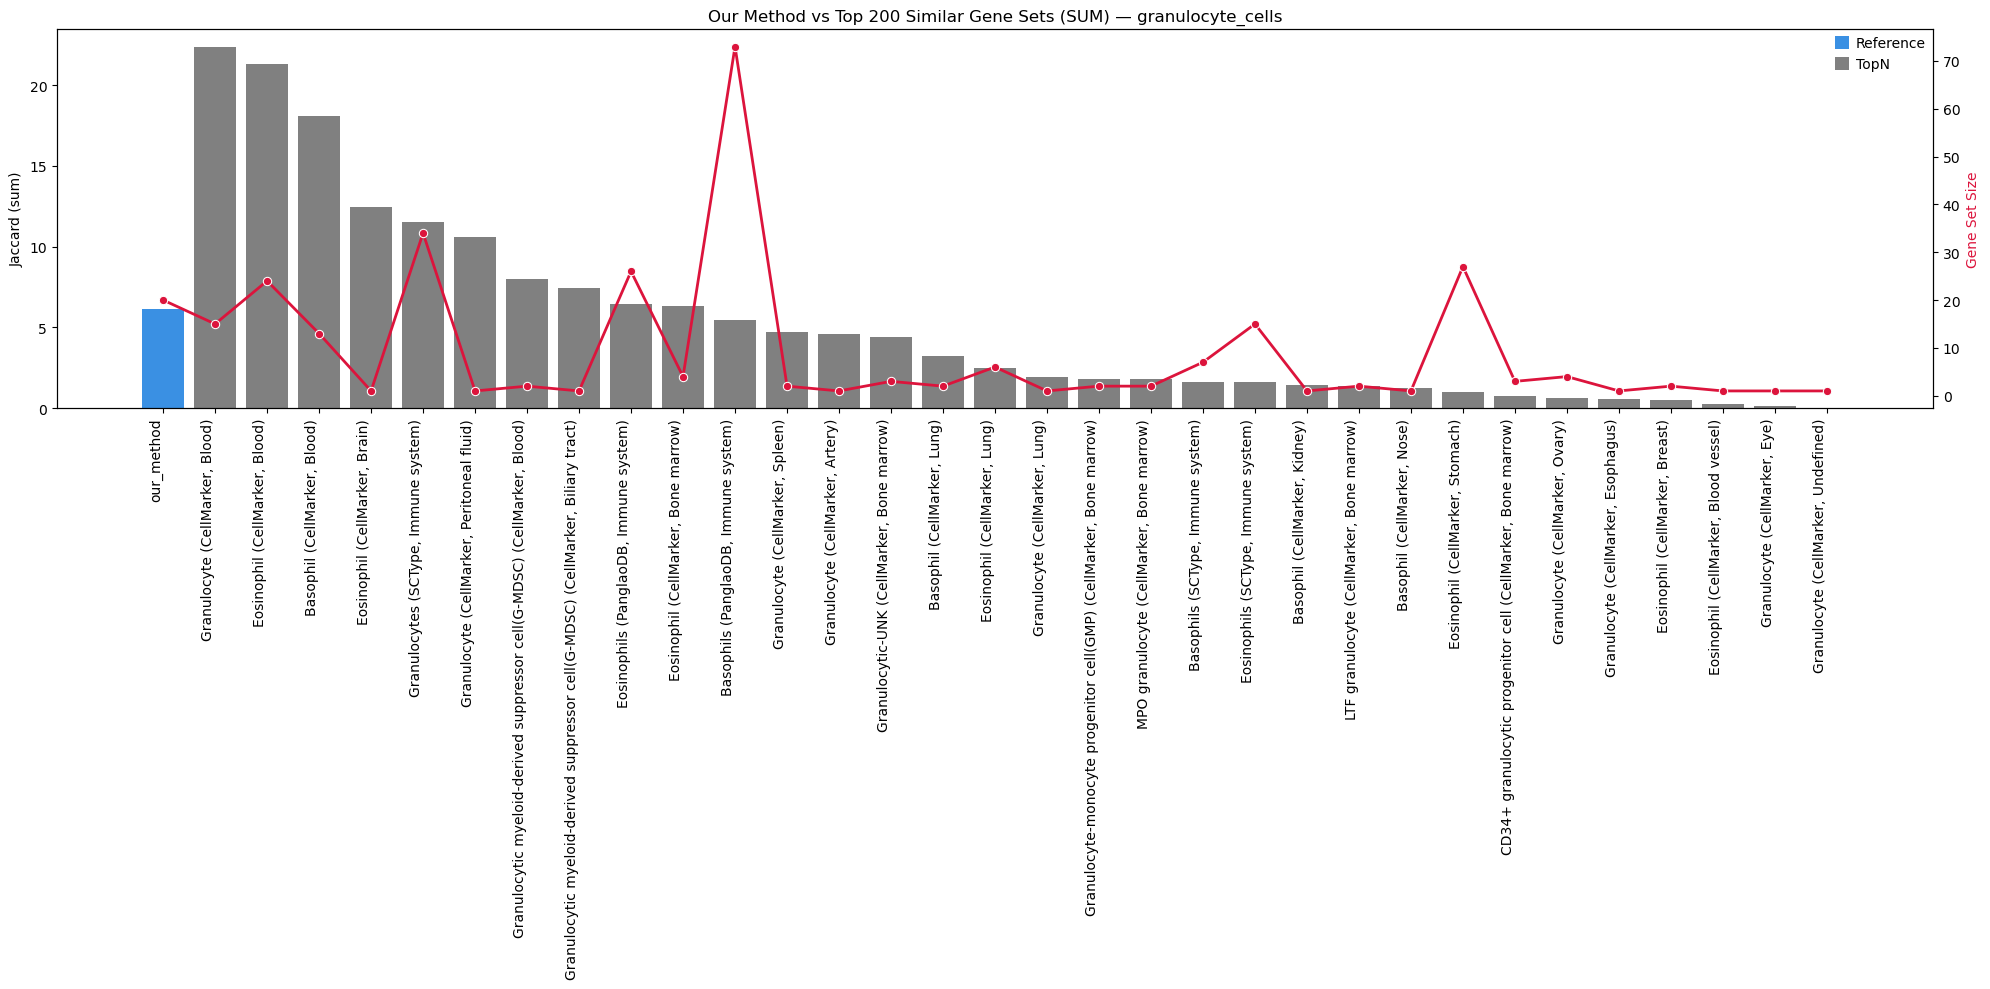

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/macrophage_cells_top200_sum.pdf


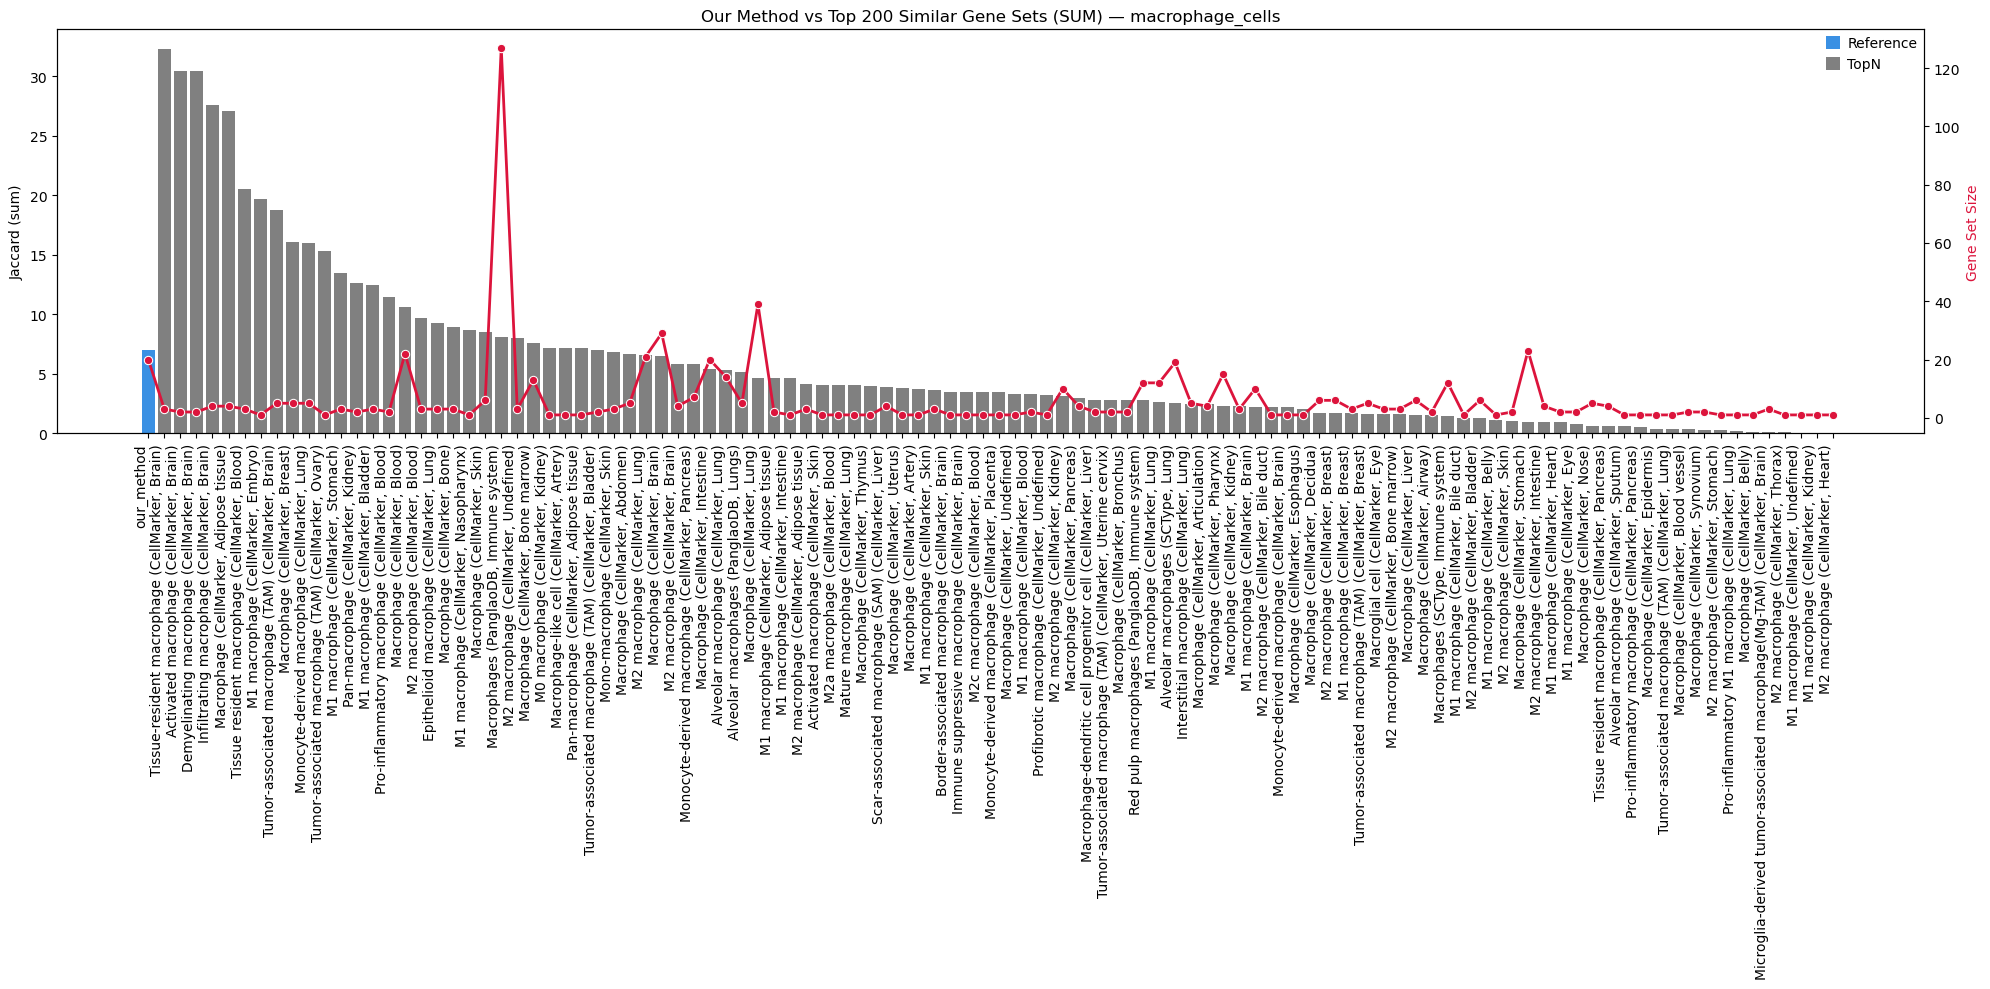

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/nk_cells_top200_sum.pdf


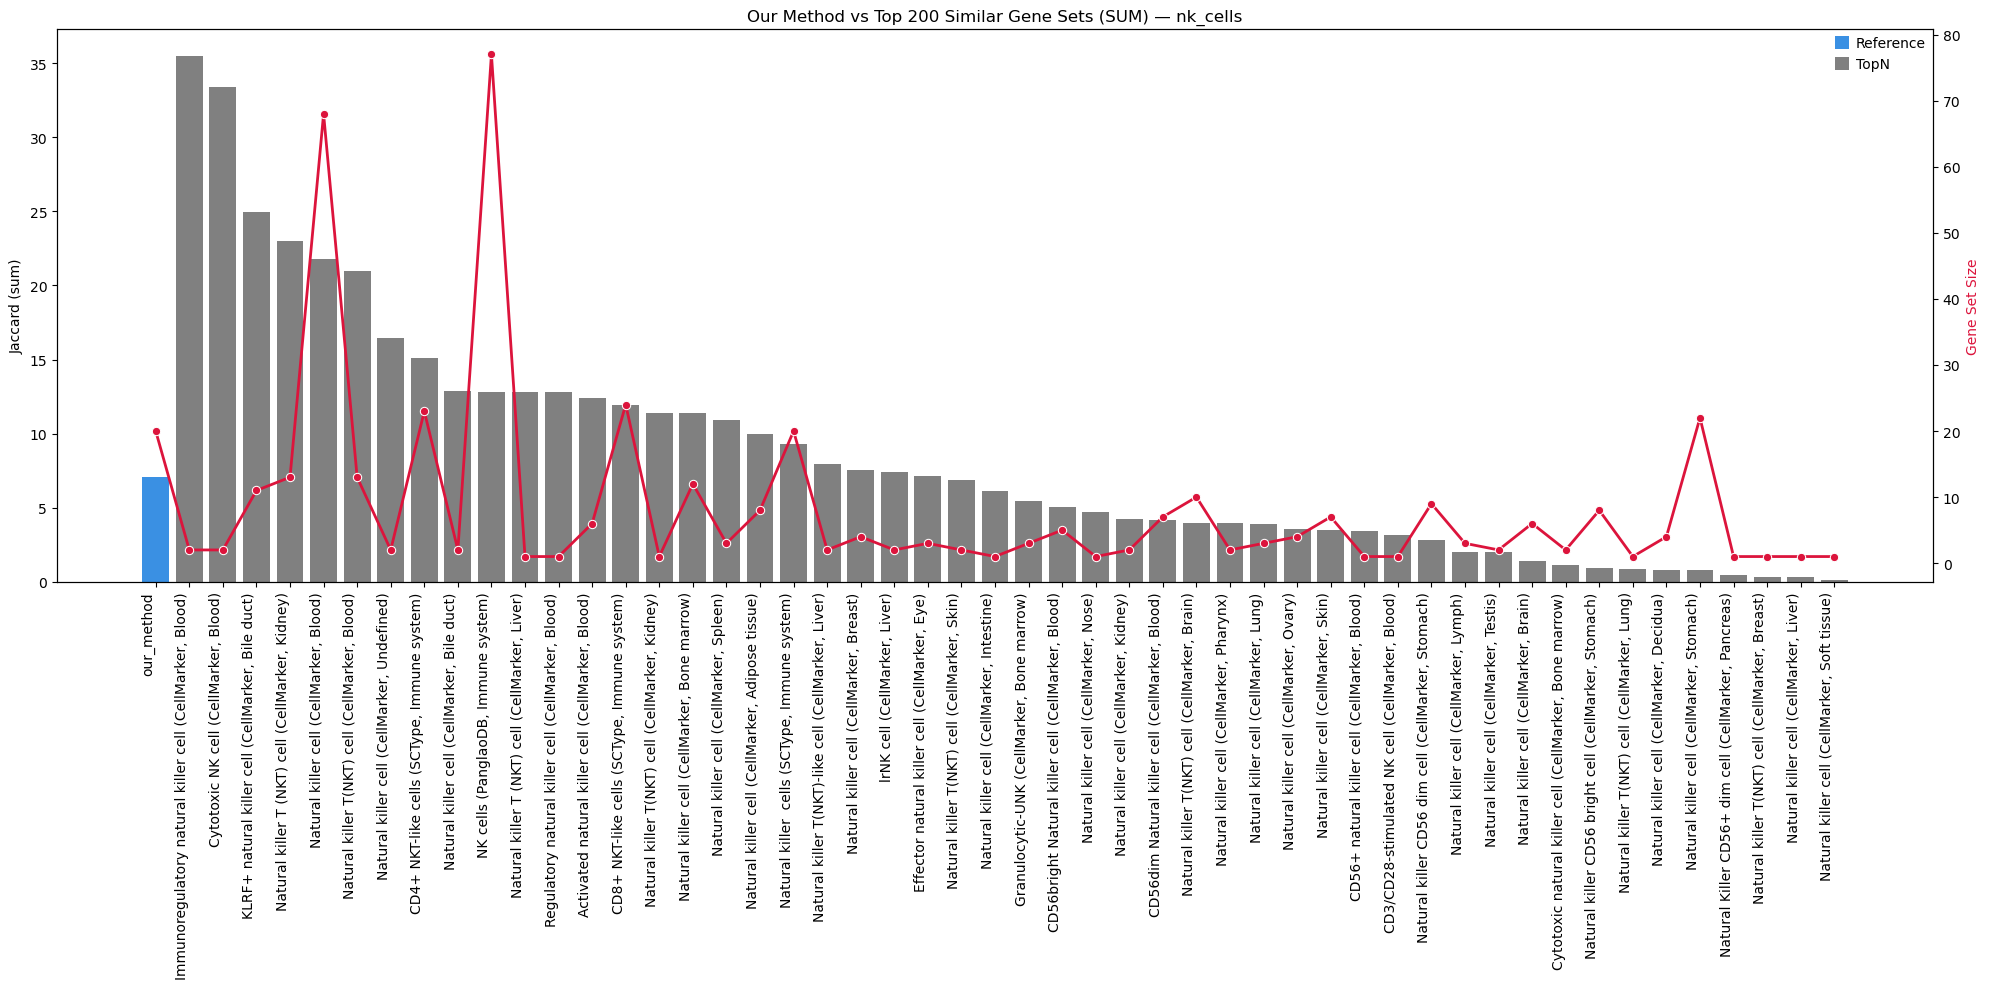

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/plasma_cells_top200_sum.pdf


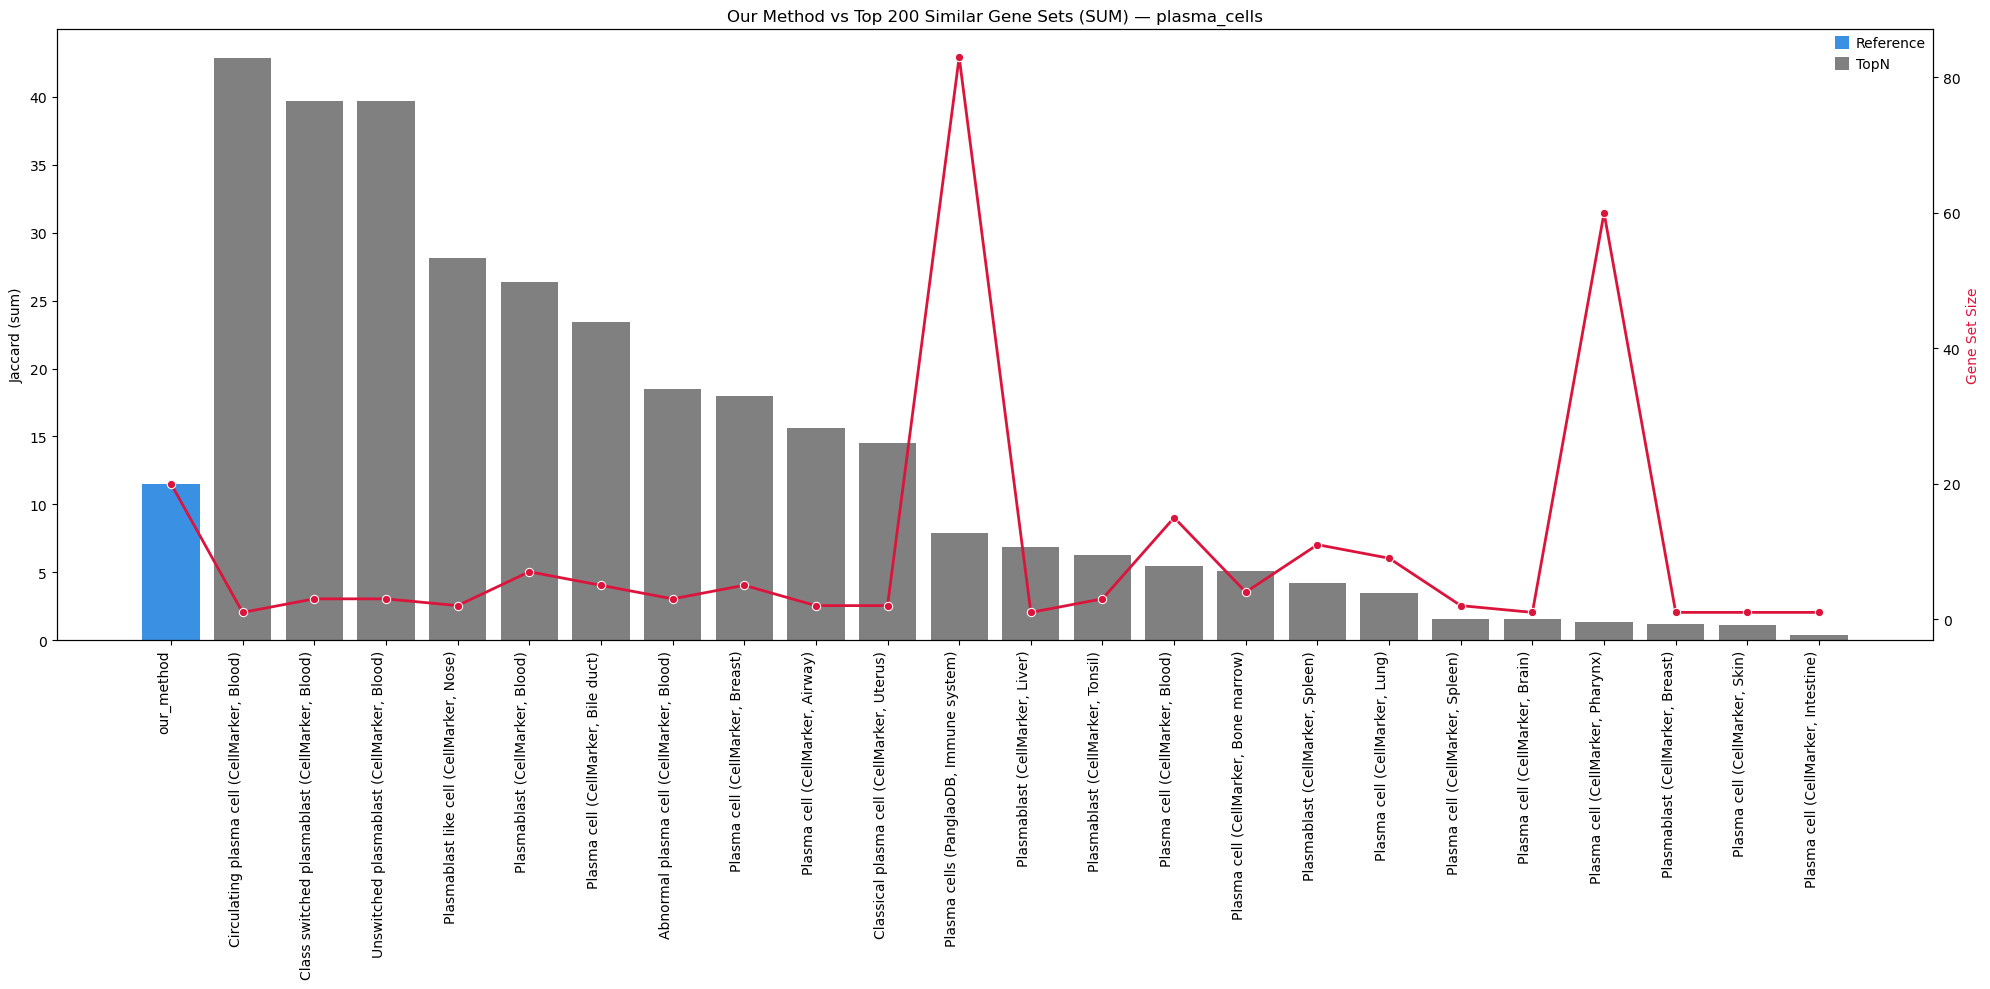

/scratch/local/jobs/166190/ipykernel_1164167/3786361816.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")


✅ Saved: ../Figures/barplots/t_cells_top200_sum.pdf


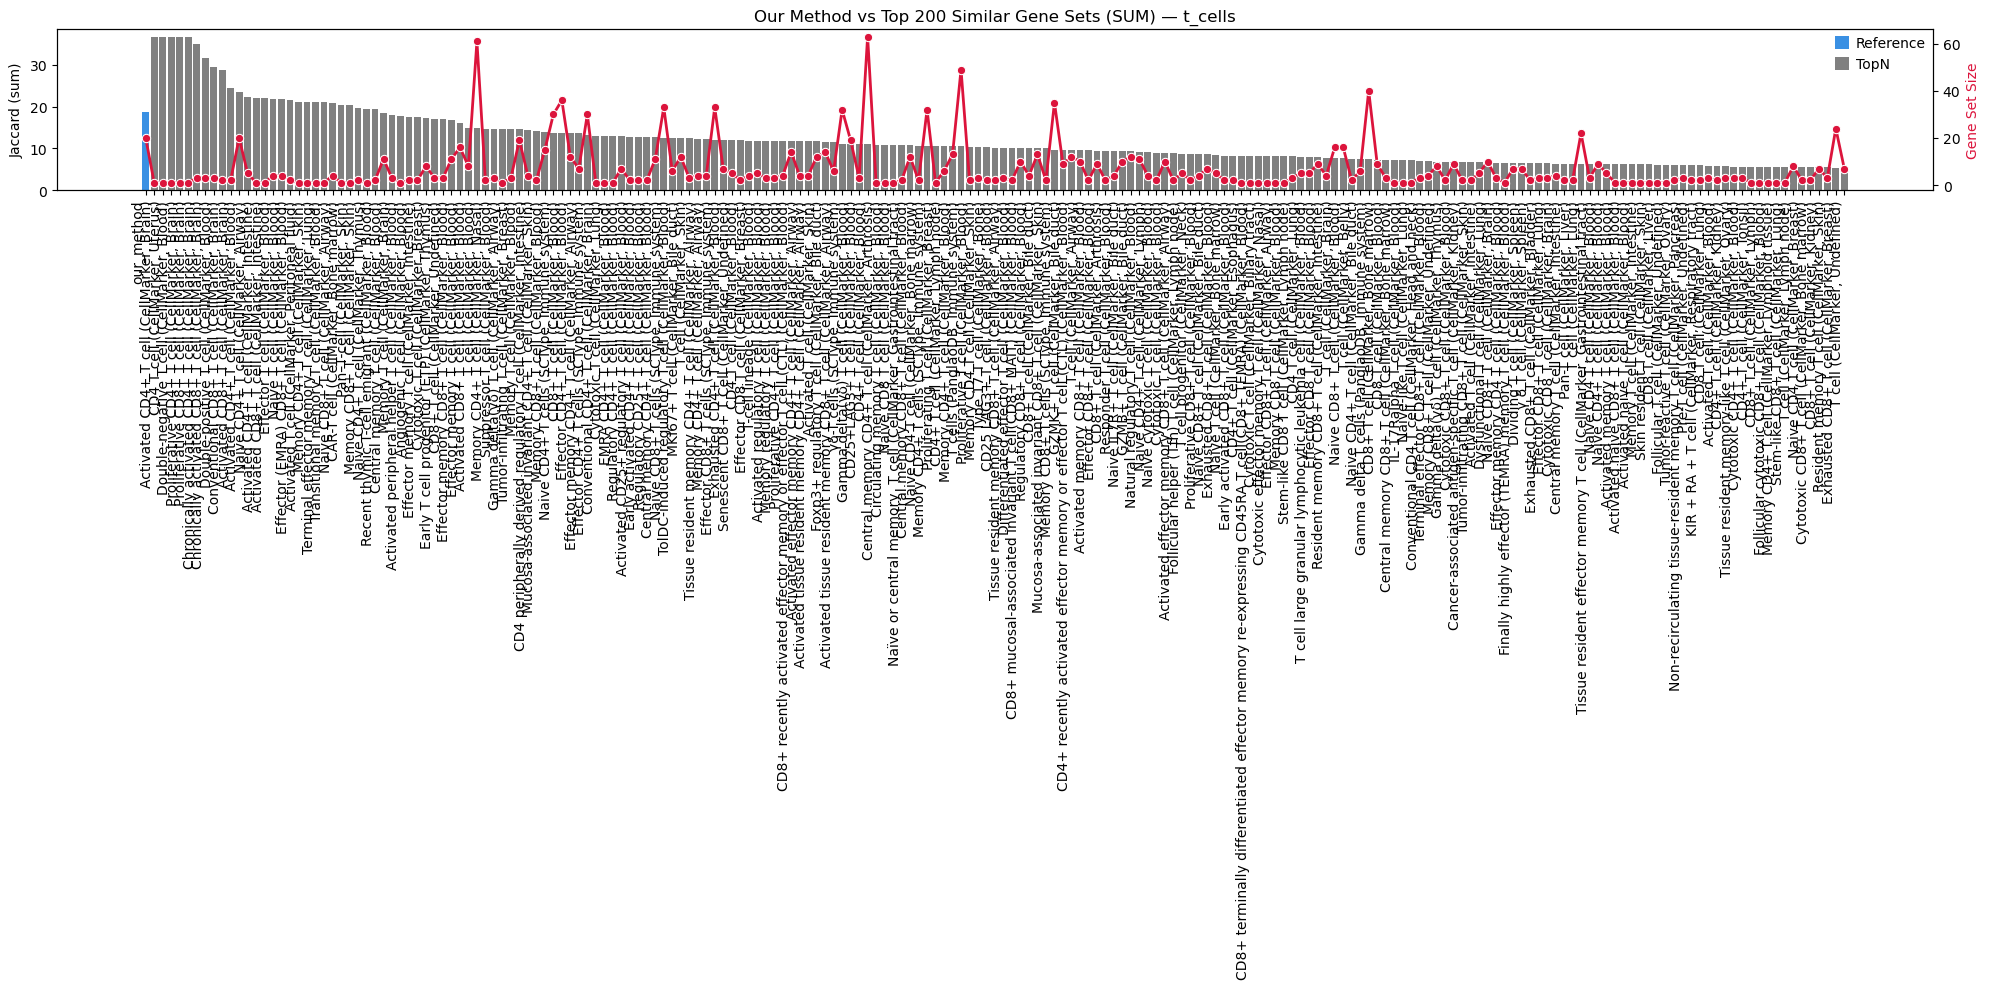

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# === User-configurable variables ===
use_agg = "sum"   # options: "sum", "mean", "max", "median"
top_n = 200         # number of top similar gene sets to display
ref_geneset_size = 20  # size of your reference (our_method) gene set

# === 1. Filter Jaccard values (our_method vs refined groups only) ===
ref_vs_refined = all_jaccard_df[
    (all_jaccard_df["is_ref"] == False) &
    (all_jaccard_df["refined_cell_type"].notna())
].copy()

# === 2. Aggregate Jaccard per refined group per x ===
agg_df = (
    ref_vs_refined
    .groupby(["x", "refined_cell_type", "refined_db", "refined_tissue"], as_index=False)
    .agg({"jaccard_value": use_agg})
    .rename(columns={"jaccard_value": f"jaccard_{use_agg}"})
)

# === 3. Compute gene set sizes from combined_database ===
geneset_sizes = (
    combined_database
    .groupby(["cell_type", "db", "tissue"])
    .size()
    .reset_index(name="geneset_size")
)

# merge sizes into aggregated data
agg_df = agg_df.merge(
    geneset_sizes,
    left_on=["refined_cell_type", "refined_db", "refined_tissue"],
    right_on=["cell_type", "db", "tissue"],
    how="left"
).drop(columns=["cell_type", "db", "tissue"])

# === 4. Select top N refined groups per x ===
top_refined = (
    agg_df
    .sort_values(["x", f"jaccard_{use_agg}"], ascending=[True, False])
    .groupby("x")
    .head(top_n)
)

# === 5. Aggregate our_method (reference) the same way ===
ref_df = (
    all_jaccard_df[all_jaccard_df["is_ref"] == True]
    .groupby("x", as_index=False)["jaccard_value"]
    .agg(use_agg)
    .rename(columns={"jaccard_value": f"ref_value_{use_agg}"})
)

# === 6. Plot reference + top N refined groups for each x ===
for x in top_refined["x"].unique():
    ref_val = ref_df.loc[ref_df["x"] == x, f"ref_value_{use_agg}"].values[0]
    sub_df = top_refined[top_refined["x"] == x].copy()

    # Prepare data for plotting
    plot_data = pd.DataFrame({
        "Label": ["our_method"] + [
            f"{a} ({b}, {c})" for a, b, c in zip(
                sub_df["refined_cell_type"], sub_df["refined_db"], sub_df["refined_tissue"]
            )
        ],
        "Jaccard": [ref_val] + sub_df[f"jaccard_{use_agg}"].tolist(),
        "GeneSet_Size": [ref_geneset_size] + sub_df["geneset_size"].tolist(),
        "Type": ["Reference"] + ["TopN"] * len(sub_df)
    })

    fig, ax1 = plt.subplots(figsize=(20, 10))

    # --- Primary axis: Jaccard values ---
    sns.barplot(
        data=plot_data,
        x="Label",
        y="Jaccard",
        hue="Type",
        dodge=False,
        palette={"Reference": "dodgerblue", "TopN": "gray"},
        ax=ax1
    )
    ax1.set_ylabel(f"Jaccard ({use_agg})", color="black")

    # --- Secondary axis: Gene set size ---
    ax2 = ax1.twinx()
    sns.lineplot(
        data=plot_data,
        x="Label",
        y="GeneSet_Size",
        color="crimson",
        marker="o",
        linewidth=2,
        ax=ax2
    )
    ax2.set_ylabel("Gene Set Size", color="crimson")

    # --- Formatting ---
    plt.title(f"Our Method vs Top {top_n} Similar Gene Sets ({use_agg.upper()}) — {x}")
    ax1.set_xlabel("")
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha="right")
    ax1.legend().set_title("")
    plt.tight_layout()

    # --- Save plot ---
    filename = f"{x.replace(' ', '_')}_top{top_n}_{use_agg}.pdf"
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    print(f"✅ Saved: {filepath}")

    plt.show()